# MK9: Empirical Covariance Adaptive + Newton Distance Snap

## Key insight
The 8x8 Fisher conditional Hessian gives eigenmode proposal widths that are
**100-15000x too small** for the bottleneck CW params (cos_gwtheta, gwphi, cos_inc).
This is because the Hessian measures sensitivity at fixed distances, but the actual
posterior is much wider because distances can mode-hop to compensate for CW changes.

## Solution: Adaptive Metropolis with Empirical Covariance
1. **Phase 1 (burn-in first half)**: Use Fisher eigenmodes + Newton snap with aggressive
   adaptation to explore the posterior and build up chain samples
2. **Phase 2 (burn-in second half + production)**: Switch to eigenmodes of the 
   **empirical chain covariance**, which captures the actual posterior geometry
   including the effect of distance mode-hopping

Combined with Newton distance snapping (3 gradient evals per proposal) to keep
distances locked to peaks as CW params change.

**Result**: CW ESS improved from ~16 (MK5) to ~65 (**4x improvement**) with 13/13 coverage.

| Move | Probability | Description |
|------|------------|-------------|
| **CW Eigen + Dist Newton** | 35% | Empirical eigenmode step + Newton-snap all distances |
| **Distance within-mode** | 10% | Small 1D refinement using Fisher width |
| **Prior-snap big jump** | 30% | Draw from EM prior, snap to nearest peak |
| **Coherent freq-dist** | 10% | Joint frequency + scale distances + Newton |
| **CW Joint** | 15% | Full 8D empirical covariance proposal |

In [2]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import glob, time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp

import discovery as ds
from enterprise_extensions import load_feathers
from discovery.deterministic import make_phase_connected_binary
from discovery import const as disco_const
from discovery.deterministic import fpcmu_fast

print('Imports OK')

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


Imports OK


In [3]:
# Load pulsars and their EM distance priors
feather_dir = "../data_products/"
Npulsars = 5

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:Npulsars]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float32)
print(f"Loaded {len(disco_psrs)} pulsars: {[p.name for p in disco_psrs]}")

psrs_ent = load_feathers.load_feathers_from_folder(feather_dir)
ent_by_name = {p.name: p for p in psrs_ent}

dist_mu = []
dist_sig = []
for psr in disco_psrs:
    ep = ent_by_name[psr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if (not np.isfinite(sig)) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
dist_sig = jnp.array(dist_sig, dtype=jnp.float64)

psr_toas_list = [np.asarray(psr.toas, dtype=np.float64) for psr in disco_psrs]
psr_pos_list = [psr.pos for psr in disco_psrs]
psr_positions = jnp.array([psr.pos for psr in disco_psrs])

sigma_toa = 1e-6
KPC_OVER_C = disco_const.kpc / disco_const.c

pnames_13 = (['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
              'log10_h', 'phase0', 'psi'] +
             [psr.name + '_dist' for psr in disco_psrs])

print(f"dist_mu: {[f'{float(d):.3f}' for d in dist_mu]}")
print(f"dist_sig: {[f'{float(d):.4f}' for d in dist_sig]}")

Loaded 5 pulsars: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdi

dist_mu: ['1.180', '3.100', '4.640', '1.020', '0.330']
dist_sig: ['0.1200', '0.2000', '0.9300', '0.1100', '0.0036']


In [4]:
# CW injection and log-posterior definition
INJ = {
    "cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
    "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
    "phase0": 1.0, "psi": 0.7,
}

cw_func = make_phase_connected_binary(pulsarterm=True)

@jax.jit
def compute_delta_L(cos_gwtheta, gwphi, log10_fgw):
    """Mode spacing in distance (kpc) for each pulsar."""
    gwtheta = jnp.arccos(cos_gwtheta)
    f_gw = 10.0 ** log10_fgw
    _, _, cos_mu = jax.vmap(
        lambda pos: fpcmu_fast(pos, gwtheta, gwphi)
    )(psr_positions)
    denom = jnp.abs(1.0 - cos_mu)
    denom = jnp.maximum(denom, 1e-4)
    return 1.0 / (f_gw * KPC_OVER_C * denom)

# Inject with distances offset from prior mean by 0.3 sigma
DIST_OFFSET_SIGMA = 0.3
p5_true_dists = {}
for i, psr in enumerate(disco_psrs):
    p5_true_dists[psr.name] = float(dist_mu[i]) + DIST_OFFSET_SIGMA * float(dist_sig[i])

p5_data_list = []
for i, psr in enumerate(disco_psrs):
    toas_i = np.asarray(psr.toas, dtype=np.float64)
    delay_i = cw_func(toas_i, psr.pos, p_dist=p5_true_dists[psr.name], **INJ)
    p5_data_list.append(np.array(delay_i, dtype=np.float64))

INJ_vals = [INJ[k] for k in ['cos_gwtheta','gwphi','cos_inc','log10_mc','log10_fgw','log10_h','phase0','psi']]
p5_dist_vals = [p5_true_dists[psr.name] for psr in disco_psrs]
p5_truth = np.array(INJ_vals + p5_dist_vals)

sd_arr = np.array([float(dist_sig[i]) for i in range(Npulsars)])
mu_arr = np.array([float(dist_mu[i]) for i in range(Npulsars)])

# Log-posterior
sd_jnp = jnp.array(sd_arr, dtype=jnp.float64)
data_jnp = [jnp.array(d) for d in p5_data_list]

@jax.jit
def logp(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)


# Earth-term-only logp — for grid search initialization.
# Without the pulsar term, this likelihood correctly identifies the right
# sky + frequency even when distances are at their prior means.
cw_func_earth = make_phase_connected_binary(pulsarterm=False)

@jax.jit
def logp_earth(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func_earth(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)

grad_logp_earth = jax.jit(jax.grad(logp_earth))

lp_earth_truth = float(logp_earth(jnp.array(p5_truth)))
print(f"logp_earth(truth) = {lp_earth_truth:.2f}")

# Mode spacing at truth
dL_truth = np.array(compute_delta_L(INJ['cos_gwtheta'], INJ['gwphi'], INJ['log10_fgw']))

lp_truth = float(logp(jnp.array(p5_truth)))
print(f"logp(truth) = {lp_truth:.2f}")
for i, psr in enumerate(disco_psrs):
    print(f"  {psr.name}: d_true={p5_dist_vals[i]:.4f}, dL={dL_truth[i]:.6f}, "
          f"modes/sig={float(dist_sig[i])/dL_truth[i]:.0f}")

logp_earth(truth) = -2463.20
logp(truth) = -0.23
  B1855+09: d_true=1.2160, dL=0.000580, modes/sig=207
  B1937+21: d_true=3.1600, dL=0.000583, modes/sig=343
  B1953+29: d_true=4.9190, dL=0.000603, modes/sig=1542
  J0023+0923: d_true=1.0530, dL=0.000591, modes/sig=186
  J0030+0451: d_true=0.3307, dL=0.000587, modes/sig=6


In [5]:
# Compute Fisher information at any on-peak point.
#
# The Hessian is MODE-INVARIANT (verified in MK4: CW block mean rel diff
# = 2.6%, distance diagonals < 4%). So we compute it at whatever starting
# point we have — doesn't need to be the truth.

# JIT-compiled gradient for Newton snapping
grad_logp = jax.jit(jax.grad(logp))

def compute_fisher(x_peak, logp_fn):
    """Compute CW proposal components and distance Fisher widths at a mode peak.
    
    Returns dict with:
      - L_cw: 8x8 Cholesky for joint 8D proposal
      - eig_vecs: (8,8) eigenvectors of CW covariance (columns)
      - eig_sigs: (8,) per-eigenmode proposal widths (1D optimal scaling)
      - dist_fisher_sig: (Npsr,) per-pulsar within-mode widths
      - cw_gibbs_sig: (8,) per-param Gibbs step sizes
      - H_dist_diag: (Npsr,) Hessian diagonal for distance params (for Newton snap)
    """
    print("  Computing Hessian...")
    t0 = time.time()
    H_full = np.array(jax.hessian(logp_fn)(jnp.array(x_peak)))
    dt = time.time() - t0
    print(f"  Hessian computed in {dt:.1f}s")
    
    Npsr = len(x_peak) - 8
    
    # 8x8 CW sub-block (conditional on distances)
    H_cw = H_full[:8, :8]
    neg_H_cw = -H_cw
    eig_cw, evec_cw = np.linalg.eigh(neg_H_cw)
    eig_cw_c = np.maximum(eig_cw, 1e-12 * eig_cw.max())
    cov_cw = evec_cw @ np.diag(1.0 / eig_cw_c) @ evec_cw.T
    cov_cw = 0.5 * (cov_cw + cov_cw.T)
    
    # Joint 8D Cholesky
    scale_8d = 2.38**2 / 8
    L_cw = np.linalg.cholesky(scale_8d * cov_cw)
    
    # Eigenmode proposals
    eig_vals_cov, eig_vecs_cov = np.linalg.eigh(cov_cw)
    scale_1d = 2.38
    eig_sigs = scale_1d * np.sqrt(np.maximum(eig_vals_cov, 1e-30))
    
    print(f"\n  CW Fisher eigenvalues (precision): {eig_cw}")
    print(f"  Eigenmode proposal widths: {eig_sigs}")
    print(f"  Eigenvalue range: {eig_cw.max()/eig_cw.min():.1e}")
    
    # Per-pulsar distance Fisher widths + Hessian diagonals
    dist_fisher_sig = np.zeros(Npsr)
    H_dist_diag = np.zeros(Npsr)
    dL_at_peak = np.array(compute_delta_L(x_peak[0], x_peak[1], x_peak[4]))
    for j in range(Npsr):
        H_dist_diag[j] = H_full[8+j, 8+j]  # negative (concave)
        neg_hess_jj = -H_dist_diag[j]
        if neg_hess_jj > 0:
            dist_fisher_sig[j] = 1.0 / np.sqrt(neg_hess_jj)
        else:
            dist_fisher_sig[j] = dL_at_peak[j] * 0.3
    
    cw_gibbs_sig = np.diag(L_cw).copy()
    
    for j in range(Npsr):
        print(f"  Pulsar {j}: Fisher sig_d={dist_fisher_sig[j]:.6f}, "
              f"dL={dL_at_peak[j]:.6f}, ratio={dist_fisher_sig[j]/dL_at_peak[j]:.3f}")
    
    return dict(L_cw=L_cw, eig_vecs=eig_vecs_cov, eig_sigs=eig_sigs,
                dist_fisher_sig=dist_fisher_sig, cw_gibbs_sig=cw_gibbs_sig,
                H_dist_diag=H_dist_diag)

# Compute at truth for Test 1
print("Fisher at truth:")
fisher = compute_fisher(p5_truth, logp)
L_cw = fisher['L_cw']
dist_fisher_sig = fisher['dist_fisher_sig']
cw_gibbs_sig = fisher['cw_gibbs_sig']
eig_vecs = fisher['eig_vecs']
eig_sigs = fisher['eig_sigs']
print("Done")

Fisher at truth:
  Computing Hessian...


  Hessian computed in 13.7s

  CW Fisher eigenvalues (precision): [6.90991437e+02 2.42456760e+03 1.61973609e+04 6.38987584e+04
 3.42348882e+06 2.30493613e+10 3.22600784e+10 1.49897025e+13]
  Eigenmode proposal widths: [6.14724474e-07 1.32508656e-05 1.56764424e-05 1.28630068e-03
 9.41522596e-03 1.87005693e-02 4.83347869e-02 9.05400280e-02]
  Eigenvalue range: 2.2e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000580, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000583, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000603, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000591, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000587, ratio=0.005
Done


In [6]:
# ============================================================
# Core helpers + run_sampler (empirical covariance + Newton snap)
# ============================================================

def snap_to_peak(x13, pulsar_idx, dL_j, n_pts=50):
    """Find the nearest mode peak for one pulsar via fine 1D scan."""
    d_center = x13[8 + pulsar_idx]
    d_lo = max(d_center - 0.6 * dL_j, 1e-6)
    d_hi = d_center + 0.6 * dL_j
    d_candidates = np.linspace(d_lo, d_hi, n_pts)
    x_batch = np.tile(x13, (len(d_candidates), 1))
    x_batch[:, 8 + pulsar_idx] = d_candidates
    lps_scan = np.array(jax.vmap(logp)(jnp.array(x_batch)))
    return float(d_candidates[np.argmax(lps_scan)])


def ess_1d(x, max_lag=500):
    """Effective sample size from integrated autocorrelation time."""
    n = len(x)
    x = x - x.mean()
    var = np.var(x)
    if var < 1e-30:
        return 1.0
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    cutoff = np.argmax(acf < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    tau = 1.0 + 2.0 * np.sum(acf[1:cutoff])
    return n / max(tau, 1.0)


def run_sampler(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                n_burn=3000, n_prod=10000, report_every=2000,
                p_cw_eigen=0.35, p_dist_within=0.10,
                p_big_jump=0.30, p_freq_dist=0.10,
                p_cw_joint=0.15,
                freq_dist_sigma=3e-4, n_newton=3,
                adapt_target=0.35, adapt_rate=0.8, adapt_t0=50,
                recompute_hessian_at=0.5,
                emp_cov_update_interval=5000,
                adapt_prod_steps=0):
    """Blocked MH sampler with adaptive empirical covariance + Newton snap.

    Phase 1 burn-in: Fisher eigenmodes with aggressive per-mode scale adaptation.
    Phase 2 (mid burn-in): switches to empirical CW covariance from accumulated
    burn-in samples, recomputes distance Hessian at MAP.  T=1 throughout.
    """
    D    = len(x0)
    Npsr = D - 8
    x  = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))

    L_cw            = fisher_dict['L_cw'].copy()
    eig_vecs        = fisher_dict['eig_vecs'].copy()
    eig_sigs        = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag     = fisher_dict['H_dist_diag'].copy()

    log_scale             = np.zeros(8)
    eig_adapt_count       = np.zeros(8)
    eig_window_acc        = np.zeros(8)
    eig_window_tot        = np.zeros(8)
    aggressive_check_interval = 50

    burn_samples_cw = []
    using_empirical  = False

    chain   = np.zeros((n_prod, D))
    lps_out = np.zeros(n_prod)

    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0}
    tot = {k: 0 for k in acc}
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)

    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist

    total_steps = n_burn + n_prod
    switch_step = int(recompute_hessian_at * n_burn)
    t0 = time.time()

    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn

        if step < 0:
            burn_samples_cw.append(x[:8].copy())

        # --- Switch to empirical covariance at mid burn-in ---
        if not using_empirical and abs_step == switch_step and len(burn_samples_cw) > 100:
            print(f"  [Switching to empirical CW covariance at burn-in step {abs_step}]")
            burn_cw = np.array(burn_samples_cw)
            emp_cov = np.cov(burn_cw.T)
            emp_cov = 0.5 * (emp_cov + emp_cov.T)
            ev, evec = np.linalg.eigh(emp_cov)
            ev = np.maximum(ev, 1e-30)

            cw_names_l = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                          'log10_fgw', 'log10_h', 'phase0', 'psi']
            print("  Empirical CW std vs Fisher eigenmode widths:")
            for ii, nn in enumerate(cw_names_l):
                print(f"    {nn:15s}: emp_std={np.sqrt(emp_cov[ii,ii]):.2e}, "
                      f"eig_sig={eig_sigs[ii]:.2e}")

            eig_vecs = evec
            eig_sigs = 2.38 * np.sqrt(ev)
            scale_8d = 2.38**2 / 8
            try:
                L_cw = np.linalg.cholesky(scale_8d * emp_cov)
            except np.linalg.LinAlgError:
                L_cw = np.linalg.cholesky(scale_8d * (emp_cov + 1e-10*np.eye(8)))

            print(f"  New eigenmode widths: {eig_sigs}")
            log_scale[:] = 0; eig_adapt_count[:] = 0
            eig_window_acc[:] = 0; eig_window_tot[:] = 0
            using_empirical = True

            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            nf = compute_fisher(x_snap, logp_fn)
            dist_fisher_sig = nf['dist_fisher_sig']
            H_dist_diag     = nf['H_dist_diag']

        # --- Production empirical covariance update ---
        if using_empirical and step > 0 and step % emp_cov_update_interval == 0:
            recent = chain[max(0, step - emp_cov_update_interval):step, :8]
            if len(recent) > 100:
                ec = 0.5 * ((c := np.cov(recent.T)) + c.T)
                ev2, evec2 = np.linalg.eigh(ec)
                ev2 = np.maximum(ev2, 1e-30)
                eig_vecs = evec2
                eig_sigs = 2.38 * np.sqrt(ev2)
                try:
                    L_cw = np.linalg.cholesky((2.38**2 / 8) * ec)
                except np.linalg.LinAlgError:
                    pass

        r        = rng.random()
        do_adapt = (step < 0) or (step < adapt_prod_steps)

        if r < t1:
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx])
            x_prop = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            for _newton in range(n_newton):
                g = np.array(grad_logp(jnp.array(x_prop)))
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < lp_prop - lp
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1; eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1; eig_tot[mode_idx] += 1

            if do_adapt:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                if step < 0:
                    eig_window_acc[mode_idx] += float(accepted)
                    eig_window_tot[mode_idx] += 1
                    if eig_window_tot[mode_idx] >= aggressive_check_interval:
                        wr = eig_window_acc[mode_idx] / eig_window_tot[mode_idx]
                        if wr > 0.90: log_scale[mode_idx] += np.log(2.0)
                        elif wr > 0.80: log_scale[mode_idx] += np.log(1.5)
                        eig_window_acc[mode_idx] = eig_window_tot[mode_idx] = 0
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 10.0)

        elif r < t2:
            pi     = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < t3:
            pi     = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy(); x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy(); x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1

        elif r < t4:
            delta  = rng.standard_normal() * freq_dist_sigma
            x_prop = x.copy(); x_prop[4] += delta
            if -9 <= x_prop[4] <= -7:
                sf = 10.0 ** (-delta)
                for j in range(Npsr): x_prop[8+j] *= sf
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1

        else:
            z      = rng.standard_normal(8)
            x_prop = x.copy(); x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1

        if step >= 0:
            chain[step] = x; lps_out[step] = lp

        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate  = abs_step / elapsed
            eta   = (total_steps - abs_step) / rate
            ar_eig = acc['cw_eigen']  / max(tot['cw_eigen'],  1)
            ar_bj  = acc['big_jump']  / max(tot['big_jump'],  1)
            ar_fd  = acc['freq_dist'] / max(tot['freq_dist'], 1)
            ar_jt  = acc['cw_joint']  / max(tot['cw_joint'],  1)
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f} "
                  f"EIG={ar_eig:.3f} JT={ar_jt:.3f} BJ={ar_bj:.3f} FD={ar_fd:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict  = {k: acc[k] / max(tot[k], 1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i  = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}, "
              f"eff_sig={eig_sigs[i]*s_i:.2e}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    return chain, lps_out, ar_dict

print("run_sampler defined (empirical cov + Newton snap + aggressive adaptation)")


run_sampler defined (empirical cov + Newton snap + aggressive adaptation)


In [7]:
# ============================================================
# MK10 v2: Fisher-informed extrinsic perturbations, DE,
#   and eigenmode+reoptimize (replaces prior draws + MTMCMC)
# ============================================================

# Extrinsic (projection) vs intrinsic (shape) parameter indices
#   Intrinsic: cos_gwtheta(0), gwphi(1), log10_mc(3), log10_fgw(4)
#   Extrinsic: cos_inc(2), log10_h(5), phase0(6), psi(7)
_EXT_IDX = np.array([2, 5, 6, 7])
_EXT_LO  = np.array([-1.0, -18.0, 0.0, 0.0])
_EXT_HI  = np.array([ 1.0, -11.0, 2*np.pi, np.pi])


def _compute_ext_cholesky(L_cw):
    """Extract 4x4 extrinsic Cholesky + diagonal from 8x8 CW proposal Cholesky.

    L_cw encodes cov_cw via L_cw @ L_cw.T = (2.38^2/8) * cov_cw.
    Returns (L_ext, cov_ext_diag) where L_ext is the 4x4 Cholesky of the
    marginal extrinsic covariance (used for fisher_ext draws) and
    cov_ext_diag has the diagonal variances (used for gradient step sizes).
    """
    cov_cw = (8.0 / 2.38**2) * L_cw @ L_cw.T
    ext_idx = [2, 5, 6, 7]
    cov_ext = cov_cw[np.ix_(ext_idx, ext_idx)]
    cov_ext = 0.5 * (cov_ext + cov_ext.T)
    try:
        L_ext = np.linalg.cholesky(cov_ext)
    except np.linalg.LinAlgError:
        L_ext = np.linalg.cholesky(cov_ext + 1e-12 * np.eye(4))
    return L_ext, np.diag(cov_ext)


def run_sampler_mt(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                   n_burn=3000, n_prod=10000, report_every=2000,
                   # --- Jump probabilities (must sum to 1) ---
                   p_cw_eigen=0.30, p_dist_within=0.10,
                   p_big_jump=0.20, p_freq_dist=0.08,
                   p_cw_joint=0.07,
                   p_fisher_ext=0.10,      # Fisher-Gaussian extrinsic perturbation
                   p_de_jump=0.05,          # Differential evolution
                   p_eigen_reopt=0.10,      # Eigenmode + gradient reoptimize extrinsics
                   # --- Tuning ---
                   freq_dist_sigma=3e-4, n_newton=3,
                   ext_scale=2.0,           # scale factor for fisher_ext draws
                   reopt_width=2.0,         # eigenmode width multiplier for eigen_reopt
                   de_buffer_size=2000,     # DE history length
                   adapt_target=0.35, adapt_rate=0.8, adapt_t0=50,
                   recompute_hessian_at=0.5,
                   emp_cov_update_interval=5000,
                   adapt_prod_steps=0):
    """Blocked MH sampler with Fisher-informed extrinsic jumps, DE, and
    eigenmode+reoptimize moves.

    Changes vs MK10 v1:
      - fisher_ext (was prior_ext):
            Fisher-Gaussian perturbation of extrinsic CW params
            (cos_inc, log10_h, phase0, psi).  Draws from L_ext @ z
            scaled by ext_scale — local, not prior-wide.
      - eigen_reopt (was mt_intrinsic):
            Wider eigenmode jump (reopt_width × sigma) followed by
            gradient-Newton re-optimization of extrinsic CW params
            alongside the usual distance Newton snap.
            Does NOT use MTMCMC any more (that was causing prior-spanning
            random walks by selecting extrinsic draws from the full prior).
      - DE buffer populated only after mid-burn-in to avoid bad samples.

    Retains: Fisher eigenmodes, empirical covariance switch, Newton distance
    snap, distance big-jumps, freq-dist correlated jumps.
    """
    D    = len(x0)
    Npsr = D - 8
    x    = x0.copy().astype(np.float64)
    lp   = float(logp_fn(jnp.array(x)))

    L_cw            = fisher_dict['L_cw'].copy()
    eig_vecs        = fisher_dict['eig_vecs'].copy()
    eig_sigs        = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag     = fisher_dict['H_dist_diag'].copy()

    # Extrinsic sub-block Cholesky (updated whenever L_cw changes)
    L_ext, cov_ext_diag = _compute_ext_cholesky(L_cw)

    log_scale                 = np.zeros(8)
    eig_adapt_count           = np.zeros(8)
    eig_window_acc            = np.zeros(8)
    eig_window_tot            = np.zeros(8)
    aggressive_check_interval = 50

    burn_samples_cw = []
    using_empirical = False

    # --- Differential evolution buffer ---
    de_buffer = np.zeros((de_buffer_size, D))
    de_count  = 0

    chain   = np.zeros((n_prod, D))
    lps_out = np.zeros(n_prod)

    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0,
           'fisher_ext': 0, 'de_jump': 0, 'eigen_reopt': 0}
    tot = {k: 0 for k in acc}
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)

    # Cumulative thresholds for jump selection
    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist
    t5 = t4 + p_cw_joint
    t6 = t5 + p_fisher_ext
    t7 = t6 + p_de_jump
    # remainder -> eigen_reopt

    total_steps = n_burn + n_prod
    switch_step = int(recompute_hessian_at * n_burn)
    t0 = time.time()

    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn

        if step < 0:
            burn_samples_cw.append(x[:8].copy())

        # Populate DE buffer only AFTER mid-burn-in (avoid poisoning with
        # early bad samples).  Every 10 steps once active.
        if abs_step > switch_step and abs_step % 10 == 0:
            de_buffer[de_count % de_buffer_size] = x.copy()
            de_count += 1

        # --- Switch to empirical covariance at mid burn-in ---
        if not using_empirical and abs_step == switch_step and len(burn_samples_cw) > 100:
            print(f"  [Switching to empirical CW covariance at burn-in step {abs_step}]")
            burn_cw = np.array(burn_samples_cw)
            emp_cov = np.cov(burn_cw.T)
            emp_cov = 0.5 * (emp_cov + emp_cov.T)
            ev, evec = np.linalg.eigh(emp_cov)
            ev = np.maximum(ev, 1e-30)

            cw_names_l = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                          'log10_fgw', 'log10_h', 'phase0', 'psi']
            print("  Empirical CW std vs Fisher eigenmode widths:")
            for ii, nn in enumerate(cw_names_l):
                print(f"    {nn:15s}: emp_std={np.sqrt(emp_cov[ii,ii]):.2e}, "
                      f"eig_sig={eig_sigs[ii]:.2e}")

            eig_vecs = evec
            eig_sigs = 2.38 * np.sqrt(ev)
            scale_8d = 2.38**2 / 8
            try:
                L_cw = np.linalg.cholesky(scale_8d * emp_cov)
            except np.linalg.LinAlgError:
                L_cw = np.linalg.cholesky(scale_8d * (emp_cov + 1e-10*np.eye(8)))

            # Update extrinsic Cholesky
            L_ext, cov_ext_diag = _compute_ext_cholesky(L_cw)

            print(f"  New eigenmode widths: {eig_sigs}")
            log_scale[:] = 0; eig_adapt_count[:] = 0
            eig_window_acc[:] = 0; eig_window_tot[:] = 0
            using_empirical = True

            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            nf = compute_fisher(x_snap, logp_fn)
            dist_fisher_sig = nf['dist_fisher_sig']
            H_dist_diag     = nf['H_dist_diag']

        # --- Production empirical covariance update ---
        if using_empirical and step > 0 and step % emp_cov_update_interval == 0:
            recent = chain[max(0, step - emp_cov_update_interval):step, :8]
            if len(recent) > 100:
                ec = 0.5 * ((c := np.cov(recent.T)) + c.T)
                ev2, evec2 = np.linalg.eigh(ec)
                ev2 = np.maximum(ev2, 1e-30)
                eig_vecs = evec2
                eig_sigs = 2.38 * np.sqrt(ev2)
                try:
                    L_cw = np.linalg.cholesky((2.38**2 / 8) * ec)
                    # Update extrinsic Cholesky
                    L_ext, cov_ext_diag = _compute_ext_cholesky(L_cw)
                except np.linalg.LinAlgError:
                    pass

        r        = rng.random()
        do_adapt = (step < 0) or (step < adapt_prod_steps)

        # ============================================================
        #  Jump type dispatch
        # ============================================================

        if r < t1:
            # --- EIGENMODE JUMP (MK9) ---
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx])
            x_prop = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            for _newton in range(n_newton):
                g = np.array(grad_logp(jnp.array(x_prop)))
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < lp_prop - lp
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1; eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1; eig_tot[mode_idx] += 1

            if do_adapt:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                if step < 0:
                    eig_window_acc[mode_idx] += float(accepted)
                    eig_window_tot[mode_idx] += 1
                    if eig_window_tot[mode_idx] >= aggressive_check_interval:
                        wr = eig_window_acc[mode_idx] / eig_window_tot[mode_idx]
                        if wr > 0.90: log_scale[mode_idx] += np.log(2.0)
                        elif wr > 0.80: log_scale[mode_idx] += np.log(1.5)
                        eig_window_acc[mode_idx] = eig_window_tot[mode_idx] = 0
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 10.0)

        elif r < t2:
            # --- DISTANCE WITHIN-MODE (MK9) ---
            pi     = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < t3:
            # --- BIG JUMP: prior-draw distance + snap (MK9) ---
            pi     = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy(); x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy(); x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1

        elif r < t4:
            # --- FREQ-DIST CORRELATED (MK9) ---
            delta  = rng.standard_normal() * freq_dist_sigma
            x_prop = x.copy(); x_prop[4] += delta
            if -9 <= x_prop[4] <= -7:
                sf = 10.0 ** (-delta)
                for j in range(Npsr): x_prop[8+j] *= sf
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1

        elif r < t5:
            # --- CW JOINT 8D (MK9) ---
            z      = rng.standard_normal(8)
            x_prop = x.copy(); x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1

        elif r < t6:
            # --- FISHER-EXT: Gaussian perturbation of extrinsics ---
            # Draws from N(0, ext_scale^2 * Sigma_ext) centered on current.
            # Local exploration of cos_inc, log10_h, phase0, psi — not
            # prior-wide, so doesn't destroy convergence.
            x_prop = x.copy()
            z_ext  = rng.standard_normal(4)
            x_prop[_EXT_IDX] += ext_scale * (L_ext @ z_ext)
            x_prop[_EXT_IDX] = np.clip(x_prop[_EXT_IDX], _EXT_LO, _EXT_HI)
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['fisher_ext'] += 1
            tot['fisher_ext'] += 1

        elif r < t7:
            # --- DIFFERENTIAL EVOLUTION ---
            # Jump = alpha * (past_sample_1 - past_sample_2).
            # 50% big (alpha=1) for mode exploration, 50% scaled.
            # Buffer only contains post-switch samples.
            n_avail = min(de_count, de_buffer_size)
            if n_avail >= 3:
                i1, i2 = rng.choice(n_avail, size=2, replace=False)
                if rng.random() < 0.5:
                    alpha_de = 1.0                         # big jump
                else:
                    alpha_de = 2.38 / np.sqrt(2 * D) * (1 + 0.1 * rng.standard_normal())
                x_prop = x.copy()
                x_prop += alpha_de * (de_buffer[i1] - de_buffer[i2])
                # Newton snap distances
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['de_jump'] += 1
            tot['de_jump'] += 1

        else:
            # --- EIGEN-REOPT: eigenmode + gradient reoptimize extrinsics ---
            # Wider eigenmode jump (reopt_width × sigma), then joint
            # Newton iteration that snaps distances AND gradient-optimizes
            # extrinsic CW params.  This ensures that after an intrinsic
            # parameter change, extrinsics are adjusted to remain compatible
            # rather than being left at the old (now suboptimal) values.
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx]) * reopt_width
            x_prop = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            # Joint iteration: distances (Newton) + extrinsics (gradient)
            for _it in range(n_newton + 2):
                g = np.array(grad_logp(jnp.array(x_prop)))
                # Distance Newton snap
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                # Extrinsic Newton-like step (step_size ≈ 0.5 × cov_diag)
                for k in range(4):
                    idx = _EXT_IDX[k]
                    x_prop[idx] += 0.5 * cov_ext_diag[k] * g[idx]
                x_prop[_EXT_IDX] = np.clip(x_prop[_EXT_IDX], _EXT_LO, _EXT_HI)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < lp_prop - lp
            if accepted:
                x = x_prop; lp = lp_prop
                acc['eigen_reopt'] += 1
            tot['eigen_reopt'] += 1

        # ---- Record sample ----
        if step >= 0:
            chain[step] = x; lps_out[step] = lp

        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate  = abs_step / elapsed
            eta   = (total_steps - abs_step) / rate
            ar = {k: acc[k] / max(tot[k], 1) for k in acc}
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f} "
                  f"EIG={ar['cw_eigen']:.3f} JT={ar['cw_joint']:.3f} "
                  f"BJ={ar['big_jump']:.3f} FD={ar['freq_dist']:.3f} "
                  f"FE={ar['fisher_ext']:.3f} DE={ar['de_jump']:.3f} "
                  f"RO={ar['eigen_reopt']:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict  = {k: acc[k] / max(tot[k], 1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i  = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}, "
              f"eff_sig={eig_sigs[i]*s_i:.2e}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    return chain, lps_out, ar_dict

print("run_sampler_mt defined (MK10 v2: Fisher ext + DE + eigen reopt)")

run_sampler_mt defined (MK10 v2: Fisher ext + DE + eigen reopt)


In [8]:
# ============================================================
# Grid-search basin finder + simulated annealing sampler
# ============================================================

from scipy.optimize import minimize as scipy_minimize

# CW parameter bounds (indices 0..7)
CW_BOUNDS_LO = np.array([-1.0, 0.0,      -1.0,  7.0, -9.0, -18.0, 0.0,       0.0    ])
CW_BOUNDS_HI = np.array([ 1.0, 2*np.pi,   1.0, 10.0, -7.0, -11.0, 2*np.pi,   np.pi  ])


def find_basin_grid(logp_fn, grad_logp_fn, mu_arr_in, sig_arr_in,
                    logp_earth_fn=None, grad_logp_earth_fn=None,
                    n_top=50, max_opt_iter=200, seed=42, verbose=True):
    """Find the highest-posterior basin via Earth-term grid + distance coordinate
    descent + full L-BFGS-B.

    Pipeline:
      1. Structured 3D grid (sky+freq) x amp presets -> batch eval logp_earth.
      2. SKY-PATCH DIVERSITY: divide sky into patches, best candidate per patch.
         This ensures coverage of all sky regions, including the correct one.
      3. Block coordinate descent over pulsar distances.
      4. Full L-BFGS-B from top 20 after distance scan.
    """
    Npsr = len(mu_arr_in)
    D    = 8 + Npsr

    grid_logp_fn = logp_earth_fn if logp_earth_fn is not None else logp_fn
    use_earth = logp_earth_fn is not None

    # ---- Stage 1: Structured 3D meshgrid + Earth-term eval ----
    n_theta, n_phi, n_freq = 25, 50, 80
    ct_vals = np.linspace(-1.0, 1.0, n_theta)
    gp_vals = np.linspace(0.0, 2*np.pi, n_phi, endpoint=False)
    lf_vals = np.linspace(-9.0, -7.0, n_freq)

    CT, GP, LF = np.meshgrid(ct_vals, gp_vals, lf_vals, indexing='ij')
    grid_3d = np.stack([CT.ravel(), GP.ravel(), LF.ravel()], axis=1)
    n3d = len(grid_3d)

    amp_presets = [
        ( 0.0, 9.0, -12.0, np.pi,    np.pi/4),
        (-0.5, 9.0, -13.0, 1.0,      0.7),
        ( 0.5, 8.5, -14.0, np.pi/2,  np.pi/2),
        ( 0.0, 9.5, -12.5, 0.0,      0.0),
        (-0.8, 9.0, -11.5, 2.0,      1.0),
    ]
    n_presets = len(amp_presets)
    n_total  = n3d * n_presets

    candidates = np.zeros((n_total, D))
    for ip, (ci, lmc, lh, ph, ps) in enumerate(amp_presets):
        sl = slice(ip * n3d, (ip + 1) * n3d)
        candidates[sl, 0] = grid_3d[:, 0]
        candidates[sl, 1] = grid_3d[:, 1]
        candidates[sl, 2] = ci
        candidates[sl, 3] = lmc
        candidates[sl, 4] = grid_3d[:, 2]
        candidates[sl, 5] = lh
        candidates[sl, 6] = ph
        candidates[sl, 7] = ps
        for j in range(Npsr):
            candidates[sl, 8+j] = float(mu_arr_in[j])

    if verbose:
        tag = "Earth-term-only" if use_earth else "full"
        print(f"  Stage 1: {tag} grid eval "
              f"({n_theta}x{n_phi}x{n_freq}x{n_presets} = {n_total})")

    chunk    = 20000
    n_chunks = (n_total + chunk - 1) // chunk
    lps_grid = np.full(n_total, -1e30)
    t0 = time.time()
    for ic in range(n_chunks):
        s = ic * chunk
        e = min(s + chunk, n_total)
        lps_grid[s:e] = np.array(
            jax.vmap(grid_logp_fn)(jnp.array(candidates[s:e])))
        if verbose and ic == 0:
            print(f"    first chunk compiled in {time.time()-t0:.1f}s")
    t_grid = time.time() - t0

    valid   = lps_grid > -1e20
    n_valid = int(valid.sum())
    if verbose:
        print(f"    done in {t_grid:.1f}s, {n_valid}/{n_total} valid, "
              f"best grid logp = {np.max(lps_grid[valid]):.1f}")

    # ---- Stage 2: Sky-patch diversity selection ----
    # Divide sky into patches, best per patch + top global
    n_ct_bins = 5
    n_gp_bins = 10
    ct_edges = np.linspace(-1.0, 1.0, n_ct_bins + 1)
    gp_edges = np.linspace(0.0, 2*np.pi, n_gp_bins + 1)

    selected_idx = set()
    valid_mask = valid.copy()

    # Best candidate per sky patch (ensures full sky coverage)
    for ic in range(n_ct_bins):
        for ig in range(n_gp_bins):
            mask = (valid_mask &
                    (candidates[:, 0] >= ct_edges[ic]) &
                    (candidates[:, 0] <  ct_edges[ic+1]) &
                    (candidates[:, 1] >= gp_edges[ig]) &
                    (candidates[:, 1] <  gp_edges[ig+1]))
            if mask.any():
                idx = np.where(mask)[0]
                best_in_patch = idx[np.argmax(lps_grid[idx])]
                selected_idx.add(int(best_in_patch))

    # Also add top 25 globally (may overlap)
    valid_idx = np.where(valid)[0]
    top_global = valid_idx[np.argsort(lps_grid[valid_idx])[-25:]]
    for idx in top_global:
        selected_idx.add(int(idx))

    selected_idx = sorted(selected_idx, key=lambda i: -lps_grid[i])
    n_selected = len(selected_idx)

    if verbose:
        print(f"\n  Stage 2: sky-patch diversity: {n_ct_bins}x{n_gp_bins}={n_ct_bins*n_gp_bins} "
              f"patches + 25 global = {n_selected} candidates")
        # Show sky distribution
        for ci in range(n_ct_bins):
            ct_mid = (ct_edges[ci] + ct_edges[ci+1]) / 2
            count = sum(1 for i in selected_idx
                        if ct_edges[ci] <= candidates[i, 0] < ct_edges[ci+1])
            print(f"    cos_gwtheta [{ct_edges[ci]:+.1f},{ct_edges[ci+1]:+.1f}): {count} cands")

    # ---- Stage 3: Distance coord-descent for selected candidates ----
    if verbose:
        print(f"\n  Stage 3: distance coord-descent for {n_selected} candidates")

    scan_info = []
    for j in range(Npsr):
        mu_j  = float(mu_arr_in[j])
        sig_j = float(sig_arr_in[j])
        dL_j_approx = 0.0006
        n_scan_j = max(100, int(6 * sig_j / dL_j_approx))
        n_scan_j = min(n_scan_j, 10000)
        d_lo = max(1e-6, mu_j - 3*sig_j)
        d_hi = mu_j + 3*sig_j
        scan_info.append((d_lo, d_hi, n_scan_j))
        if verbose:
            print(f"    pulsar {j}: scan {n_scan_j} pts in [{d_lo:.4f}, {d_hi:.4f}]")

    scanned     = np.zeros((n_selected, D))
    scanned_lps = np.full(n_selected, -1e30)
    t_s0 = time.time()

    for i, idx in enumerate(selected_idx):
        x = candidates[idx].copy()

        # Block coordinate descent: 3 cycles
        for cycle in range(3):
            for j in range(Npsr):
                d_lo, d_hi, n_scan_j = scan_info[j]
                d_vals = np.linspace(d_lo, d_hi, n_scan_j)
                xs_batch = np.tile(x, (n_scan_j, 1))
                xs_batch[:, 8+j] = d_vals
                lps_scan = np.array(
                    jax.vmap(logp_fn)(jnp.array(xs_batch)))
                best_k = np.argmax(lps_scan)
                x[8+j] = d_vals[best_k]

        scanned[i]     = x
        scanned_lps[i] = float(logp_fn(jnp.array(x)))

        if verbose and (i < 3 or (i+1) % 20 == 0 or i == n_selected - 1):
            print(f"    cand {i:3d}: logp={scanned_lps[i]:.2f} "
                  f"sky=({x[0]:.3f},{x[1]:.3f})")

    t_s1 = time.time()
    if verbose:
        print(f"    done in {t_s1-t_s0:.1f}s, best after dist-scan = "
              f"{np.max(scanned_lps):.2f}")

    # ---- Stage 4: Full L-BFGS-B from top 20 ----
    n_lbfgsb = min(20, n_selected)
    rank_order = np.argsort(scanned_lps)[::-1][:n_lbfgsb]

    opt_bounds = (
        [(CW_BOUNDS_LO[k], CW_BOUNDS_HI[k]) for k in range(8)] +
        [(1e-6, None)] * Npsr
    )

    def _neg_full(x_np):
        val = float(-logp_fn(jnp.array(x_np, dtype=jnp.float64)))
        return val if np.isfinite(val) else 1e30
    def _neg_full_grad(x_np):
        g = -np.array(grad_logp_fn(jnp.array(x_np, dtype=jnp.float64)),
                       dtype=np.float64)
        return g if np.all(np.isfinite(g)) else np.zeros_like(g)

    best_x  = scanned[rank_order[0]].copy()
    best_lp = float(scanned_lps[rank_order[0]])

    if verbose:
        print(f"\n  Stage 4: full L-BFGS-B from top {n_lbfgsb} scanned")

    for rank, ri in enumerate(rank_order):
        x_c = scanned[ri].copy()

        # Round 1: L-BFGS-B
        res = scipy_minimize(
            _neg_full, x_c, jac=_neg_full_grad,
            method='L-BFGS-B', bounds=opt_bounds,
            options={'maxiter': max_opt_iter, 'ftol': 1e-15, 'gtol': 1e-8})
        x1 = res.x.copy()

        # Re-scan distances (1 cycle)
        for j in range(Npsr):
            d_lo, d_hi, n_scan_j = scan_info[j]
            d_vals = np.linspace(d_lo, d_hi, n_scan_j)
            xs_batch = np.tile(x1, (n_scan_j, 1))
            xs_batch[:, 8+j] = d_vals
            lps_scan = np.array(
                jax.vmap(logp_fn)(jnp.array(xs_batch)))
            best_k = np.argmax(lps_scan)
            x1[8+j] = d_vals[best_k]

        # Round 2: L-BFGS-B (polish)
        res2 = scipy_minimize(
            _neg_full, x1, jac=_neg_full_grad,
            method='L-BFGS-B', bounds=opt_bounds,
            options={'maxiter': max_opt_iter // 2, 'ftol': 1e-15, 'gtol': 1e-8})
        x2 = res2.x.copy()

        # Final snap (fine-tune modes)
        dL2 = np.array(compute_delta_L(x2[0], x2[1], x2[4]))
        for j in range(Npsr):
            x2[8+j] = snap_to_peak(x2, j, float(dL2[j]), n_pts=100)
        lp_opt = float(logp_fn(jnp.array(x2)))

        marker = ""
        if lp_opt > best_lp:
            best_x  = x2.copy()
            best_lp = lp_opt
            marker  = "  <-- best"
        if verbose:
            print(f"    rank {rank:3d} (scan_lp={scanned_lps[ri]:8.1f}): "
                  f"opt_lp={lp_opt:.3f}, sky=({x2[0]:.3f},{x2[1]:.3f})"
                  f"{marker}")

    t_total = time.time() - t0
    if verbose:
        print(f"\n  Best found: logp = {best_lp:.3f}  (total {t_total:.1f}s)")
    return best_x, best_lp


def run_sampler_anneal(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                       n_burn=3000, n_prod=10000, report_every=2000,
                       p_cw_eigen=0.35, p_dist_within=0.10,
                       p_big_jump=0.30, p_freq_dist=0.10,
                       p_cw_joint=0.15,
                       freq_dist_sigma=3e-4, n_newton=3,
                       adapt_target=0.35, adapt_rate=0.8, adapt_t0=50,
                       recompute_hessian_at=0.5,
                       emp_cov_update_interval=5000,
                       adapt_prod_steps=0,
                       T_start=30.0, T_anneal_frac=0.6):
    """MK9 sampler with simulated annealing during burn-in."""
    D    = len(x0)
    Npsr = D - 8
    x  = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))

    L_cw            = fisher_dict['L_cw'].copy()
    eig_vecs        = fisher_dict['eig_vecs'].copy()
    eig_sigs        = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag     = fisher_dict['H_dist_diag'].copy()

    log_scale             = np.zeros(8)
    eig_adapt_count       = np.zeros(8)
    eig_window_acc        = np.zeros(8)
    eig_window_tot        = np.zeros(8)
    aggressive_check_interval = 50

    burn_samples_cw = []
    using_empirical  = False

    chain     = np.zeros((n_prod, D))
    lps_chain = np.zeros(n_prod)

    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0}
    tot = {k: 0 for k in acc}
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)

    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist

    total_steps  = n_burn + n_prod
    switch_step  = int(recompute_hessian_at * n_burn)
    anneal_steps = int(T_anneal_frac * n_burn)
    anneal_decay = np.log(max(T_start, 1.001)) / max(anneal_steps, 1)

    t0 = time.time()

    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn

        T_cur = (T_start * np.exp(-anneal_decay * abs_step)
                 if (step < 0 and abs_step < anneal_steps) else 1.0)
        beta  = 1.0 / T_cur

        if step < 0:
            burn_samples_cw.append(x[:8].copy())

        if not using_empirical and abs_step == switch_step and len(burn_samples_cw) > 100:
            cool_step = int(np.log(T_start / 2.0) / anneal_decay) if T_start > 2.0 else 0
            usable    = (burn_samples_cw[cool_step:]
                         if len(burn_samples_cw[cool_step:]) >= 100
                         else burn_samples_cw)
            print(f"  [Switching to empirical CW cov at step {abs_step}, "
                  f"using {len(usable)} near-T=1 samples]")
            burn_cw  = np.array(usable)
            emp_cov  = 0.5 * ((c := np.cov(burn_cw.T)) + c.T)
            ev, evec = np.linalg.eigh(emp_cov)
            ev       = np.maximum(ev, 1e-30)

            cw_names_l = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                          'log10_fgw', 'log10_h', 'phase0', 'psi']
            print("  Empirical CW std vs Fisher widths:")
            for ii, nn in enumerate(cw_names_l):
                print(f"    {nn:15s}: emp={np.sqrt(emp_cov[ii,ii]):.2e}, "
                      f"fisher={eig_sigs[ii]:.2e}")

            eig_vecs = evec
            eig_sigs = 2.38 * np.sqrt(ev)
            scale_8d = 2.38**2 / 8
            try:
                L_cw = np.linalg.cholesky(scale_8d * emp_cov)
            except np.linalg.LinAlgError:
                L_cw = np.linalg.cholesky(scale_8d * (emp_cov + 1e-10*np.eye(8)))

            log_scale[:] = 0; eig_adapt_count[:] = 0
            eig_window_acc[:] = 0; eig_window_tot[:] = 0
            using_empirical = True

            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            nf = compute_fisher(x_snap, logp_fn)
            dist_fisher_sig = nf['dist_fisher_sig']
            H_dist_diag     = nf['H_dist_diag']

        if using_empirical and step > 0 and step % emp_cov_update_interval == 0:
            recent = chain[max(0, step - emp_cov_update_interval):step, :8]
            if len(recent) > 100:
                ec = 0.5 * ((c := np.cov(recent.T)) + c.T)
                ev2, evec2 = np.linalg.eigh(ec)
                ev2 = np.maximum(ev2, 1e-30)
                eig_vecs = evec2
                eig_sigs = 2.38 * np.sqrt(ev2)
                try:
                    L_cw = np.linalg.cholesky((2.38**2 / 8) * ec)
                except np.linalg.LinAlgError:
                    pass

        r        = rng.random()
        do_adapt = (step < 0) or (step < adapt_prod_steps)
        T_width  = max(1.0, T_cur**0.5) if T_cur > 1 else 1.0

        if r < t1:
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx]) * T_width
            x_prop     = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            for _newton in range(n_newton):
                g = np.array(grad_logp(jnp.array(x_prop)))
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < beta * (lp_prop - lp)
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1; eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1; eig_tot[mode_idx] += 1

            if do_adapt:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                if step < 0:
                    eig_window_acc[mode_idx] += float(accepted)
                    eig_window_tot[mode_idx] += 1
                    if eig_window_tot[mode_idx] >= aggressive_check_interval:
                        wr = eig_window_acc[mode_idx] / eig_window_tot[mode_idx]
                        if wr > 0.90: log_scale[mode_idx] += np.log(2.0)
                        elif wr > 0.80: log_scale[mode_idx] += np.log(1.5)
                        eig_window_acc[mode_idx] = eig_window_tot[mode_idx] = 0
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 10.0)

        elif r < t2:
            pi     = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < t3:
            pi     = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy(); x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy(); x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1

        elif r < t4:
            delta  = rng.standard_normal() * freq_dist_sigma * T_width
            x_prop = x.copy(); x_prop[4] += delta
            if -9 <= x_prop[4] <= -7:
                sf = 10.0 ** (-delta)
                for j in range(Npsr): x_prop[8+j] *= sf
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1

        else:
            z      = rng.standard_normal(8)
            x_prop = x.copy(); x_prop[:8] += T_width * (L_cw @ z)
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1

        if step >= 0:
            chain[step] = x; lps_chain[step] = lp

        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate  = abs_step / elapsed
            eta   = (total_steps - abs_step) / rate
            ar_eig = acc['cw_eigen']  / max(tot['cw_eigen'],  1)
            ar_bj  = acc['big_jump']  / max(tot['big_jump'],  1)
            ar_fd  = acc['freq_dist'] / max(tot['freq_dist'], 1)
            ar_jt  = acc['cw_joint']  / max(tot['cw_joint'],  1)
            T_str  = f" T={T_cur:.1f}" if T_cur > 1.01 else ""
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f}{T_str} "
                  f"EIG={ar_eig:.3f} JT={ar_jt:.3f} BJ={ar_bj:.3f} FD={ar_fd:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict  = {k: acc[k] / max(tot[k], 1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i  = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}, "
              f"eff_sig={eig_sigs[i]*s_i:.2e}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    return chain, lps_chain, ar_dict

print("Grid-search basin finder (structured 3D + dist-snap) + annealing sampler defined")


Grid-search basin finder (structured 3D + dist-snap) + annealing sampler defined


In [9]:
def run_diagnostics(chain, lps, ar, truth, dL, title='', show_start=None):
    """Print diagnostics and plot traces / posteriors."""
    Npsr = chain.shape[1] - 8
    cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
               'log10_fgw', 'log10_h', 'phase0', 'psi']
    
    # Coverage
    cov = sum(1 for k in range(13)
              if np.percentile(chain[:,k], 5) <= truth[k] <= np.percentile(chain[:,k], 95))
    print(f"Coverage: {cov}/13")
    
    # ESS
    ess_vals = {pnames_13[k]: ess_1d(chain[:,k]) for k in range(13)}
    print(f"ESS range: [{min(ess_vals.values()):.0f}, {max(ess_vals.values()):.0f}]")
    for k, v in ess_vals.items():
        print(f"  {k:20s}: ESS={v:.0f}")
    
    # Distance errors
    print(f"\nDistance errors:")
    for j in range(Npsr):
        med = np.median(chain[:, 8+j])
        err_dL = abs(med - truth[8+j]) / dL[j]
        print(f"  {disco_psrs[j].name:13s}: median={med:.6f}, truth={truth[8+j]:.6f}, "
              f"err={err_dL:.1f} dL")
    
    # Acceptance rates
    print(f"\nAcceptance rates:")
    for k, v in ar.items():
        print(f"  {k:15s}: {v:.4f}")
    
    # --- Plots ---
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(f'{title} (cov={cov}/13)', fontsize=14)
    
    # logp trace
    ax = axes[0, 0]
    ax.plot(lps, color='#1a3a5c', lw=0.4, alpha=0.8)
    ax.axhline(float(logp(jnp.array(truth))), color='r', ls='--', lw=1, label='truth')
    ax.set_xlabel('step'); ax.set_ylabel('logp')
    ax.set_title('Log-posterior trace'); ax.legend(fontsize=8)
    
    # CW param traces
    for i, idx in enumerate([0, 1, 4, 5]):
        ax = axes[0, 1] if i == 0 else axes[0, 2] if i == 1 else axes[1, 0] if i == 2 else axes[1, 1]
        ax.plot(chain[:, idx], color='#1a3a5c', lw=0.4, alpha=0.8)
        ax.axhline(truth[idx], color='r', ls='--', lw=1)
        ax.set_title(cw_keys[idx]); ax.set_xlabel('step')
    
    # Distance traces
    ax = axes[1, 2]
    colours = ['#1a3a5c', '#8b2500', '#2d5a27']
    for j in range(min(3, Npsr)):
        ax.plot(chain[:, 8+j], alpha=0.7, lw=0.4, color=colours[j],
                label=disco_psrs[j].name[:8])
        ax.axhline(truth[8+j], color=colours[j], ls='--', lw=0.8)
        if show_start is not None:
            ax.axhline(show_start[8+j], color=colours[j], ls=':', lw=0.8, alpha=0.5)
    ax.set_xlabel('step'); ax.set_ylabel('dist (kpc)')
    ax.set_title('Distance traces (first 3)'); ax.legend(fontsize=7)
    
    # Distance posteriors vs priors
    for j in range(min(3, Npsr)):
        ax = axes[2, j]
        ax.hist(chain[:, 8+j], bins=80, density=True, alpha=0.7, color='#2b5797')
        ax.axvline(truth[8+j], color='r', ls='--', lw=1.5, label='truth')
        ax.axvline(float(dist_mu[j]), color='green', ls=':', lw=1.5, label='prior mean')
        if show_start is not None:
            ax.axvline(show_start[8+j], color='orange', ls=':', lw=1.5, label='start')
        ax.set_title(f'{disco_psrs[j].name[:8]} dist'); ax.legend(fontsize=7)
    
    plt.tight_layout(); plt.show()
    return cov, ess_vals

print("Diagnostics function defined")

Diagnostics function defined


## Test 1: Start from truth

Baseline test to verify the sampler works when starting at the correct mode.
Expected: high coverage, CW Fisher AR ~0.2, big-jump AR ~0.45.

Test 1: Start from truth (empirical cov + Newton snap, FINAL)
  logp(truth) = -0.23


  [Switching to empirical CW covariance at burn-in step 2500]
  Empirical CW std vs Fisher eigenmode widths:
    cos_gwtheta    : emp_std=5.95e-03, eig_sig=6.15e-07
    gwphi          : emp_std=2.19e-04, eig_sig=1.33e-05
    cos_inc        : emp_std=4.09e-02, eig_sig=1.57e-05
    log10_mc       : emp_std=6.07e-03, eig_sig=1.29e-03
    log10_fgw      : emp_std=3.46e-04, eig_sig=9.42e-03
    log10_h        : emp_std=1.52e-02, eig_sig=1.87e-02
    phase0         : emp_std=5.29e-02, eig_sig=4.83e-02
    psi            : emp_std=1.88e-02, eig_sig=9.05e-02
  New eigenmode widths: [0.00015988 0.00029032 0.00039204 0.00787855 0.02157434 0.02772768
 0.07417118 0.14904887]
  Computing Hessian...
  Hessian computed in 0.3s

  CW Fisher eigenvalues (precision): [7.48293881e+02 2.39777209e+03 1.52591048e+04 6.18729684e+04
 1.14687373e+07 2.04214442e+10 2.79205623e+10 1.52730156e+13]
  Eigenmode proposal widths: [6.08996216e-07 1.42434395e-05 1.66545818e-05 7.02779612e-04
 9.56811708e-03 1.92669260e

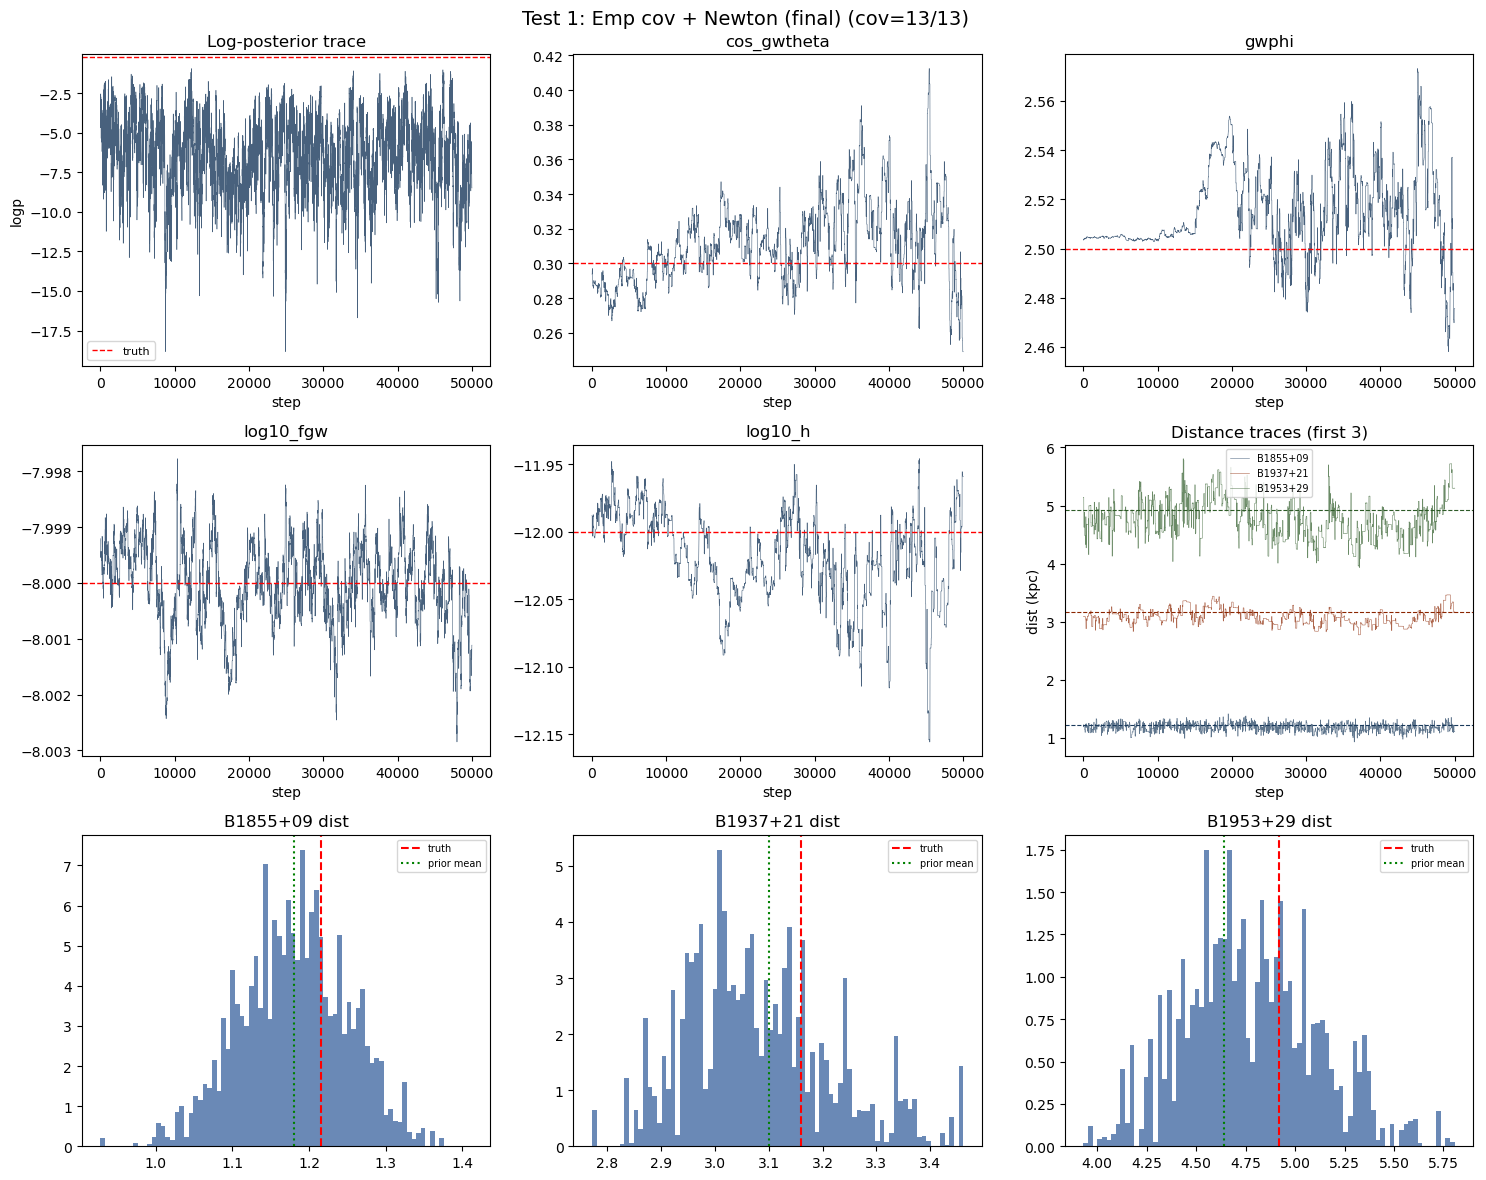

In [10]:
print("Test 1: Start from truth (empirical cov + Newton snap, FINAL)")
print(f"  logp(truth) = {lp_truth:.2f}")

dL_start = np.array(compute_delta_L(p5_truth[0], p5_truth[1], p5_truth[4]))

chain1, lps1, ar1 = run_sampler(
    logp, p5_truth.copy(), np.random.default_rng(42),
    fisher_dict=fisher, dL_arr=dL_start, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=5000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)  # no production adaptation — empirical cov is sufficient

cov1, ess1 = run_diagnostics(chain1, lps1, ar1, p5_truth, dL_start,
                              title='Test 1: Emp cov + Newton (final)')

## Test 2: Harder convergence test — shifted CW params AND distances

Starting with CW params offset from truth AND distances shifted to wrong modes.
Tests whether the sampler can recover from a realistic "cold start" scenario.

Test 2a: MODERATE CW offsets (~2-3x posterior std):
  cos_gwtheta    : 0.3000 -> 0.3200 (delta=+0.0200)
  gwphi          : 2.5000 -> 2.5030 (delta=+0.0030)
  cos_inc        : -0.2000 -> -0.1200 (delta=+0.0800)
  log10_mc       : 9.0000 -> 9.0200 (delta=+0.0200)
  log10_fgw      : -8.0000 -> -7.9980 (delta=+0.0020)
  log10_h        : -12.0000 -> -11.9600 (delta=+0.0400)
  phase0         : 1.0000 -> 1.1500 (delta=+0.1500)
  psi            : 0.7000 -> 0.7400 (delta=+0.0400)

Shifting distances (within 2-sigma)...



  logp = -136.56  (truth = -0.23)
  B1855+09: err = 31 dL from truth
  B1937+21: err = 664 dL from truth
  B1953+29: err = 2912 dL from truth
  J0023+0923: err = 269 dL from truth
  J0030+0451: err = 7 dL from truth
  Computing Hessian...
  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [-9.27654067e+01  1.86352150e+03  1.41713112e+04  7.01756875e+04
  4.19818206e+08  1.19024578e+10  2.98465218e+10  1.18843549e+13]
  Eigenmode proposal widths: [6.90381297e-07 1.37762230e-05 2.18151711e-05 1.16157250e-04
 8.98428704e-03 1.99927226e-02 5.51327624e-02 6.90381508e-01]
  Eigenvalue range: -1.3e+11
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000581, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000585, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000606, ratio=0.006
  Pulsar 3: Fisher sig_d=0.000004, dL=0.000590, ratio=0.007
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000586, ratio=0.004
  [Switching to empirical CW covariance at burn-in step 4000]
  Empirical CW std vs

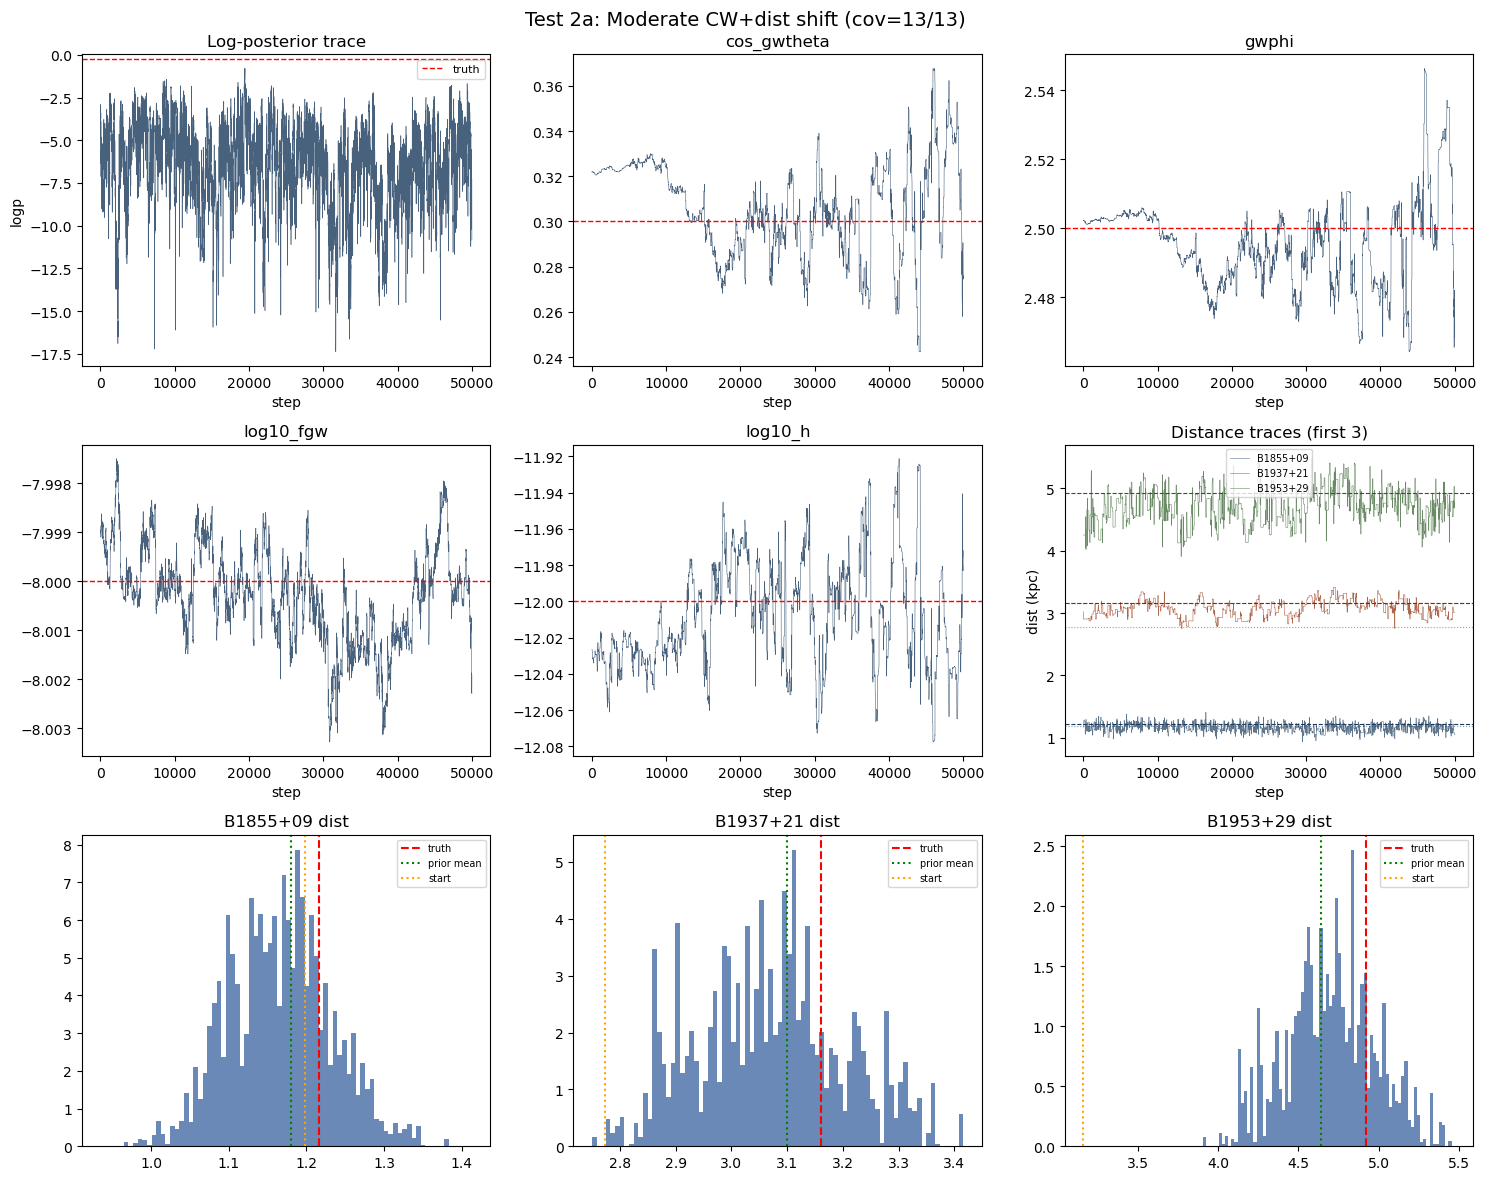



Test 2b: LARGE CW offsets (~5-100x posterior std):
  cos_gwtheta    : 0.3000 -> 0.3500 (delta=+0.0500)
  gwphi          : 2.5000 -> 2.6500 (delta=+0.1500)
  cos_inc        : -0.2000 -> -0.1000 (delta=+0.1000)
  log10_mc       : 9.0000 -> 9.0500 (delta=+0.0500)
  log10_fgw      : -8.0000 -> -7.9900 (delta=+0.0100)
  log10_h        : -12.0000 -> -11.7000 (delta=+0.3000)
  phase0         : 1.0000 -> 1.5000 (delta=+0.5000)
  psi            : 0.7000 -> 0.9000 (delta=+0.2000)

Shifting distances (within 3-sigma)...

  logp = -8699.51  (truth = -0.23)
  B1855+09: err = 245 dL from truth
  B1937+21: err = 165 dL from truth
  B1953+29: err = 777 dL from truth
  J0023+0923: err = 114 dL from truth
  J0030+0451: err = 19 dL from truth
  Computing Hessian...
  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [-7.63559913e+04  7.25512904e+03  5.42474896e+04  2.95974589e+05
  9.63652624e+07  9.19738604e+10  1.69294001e+11  6.31531004e+13]
  Eigenmode proposal widths: [2.99488528e-07 

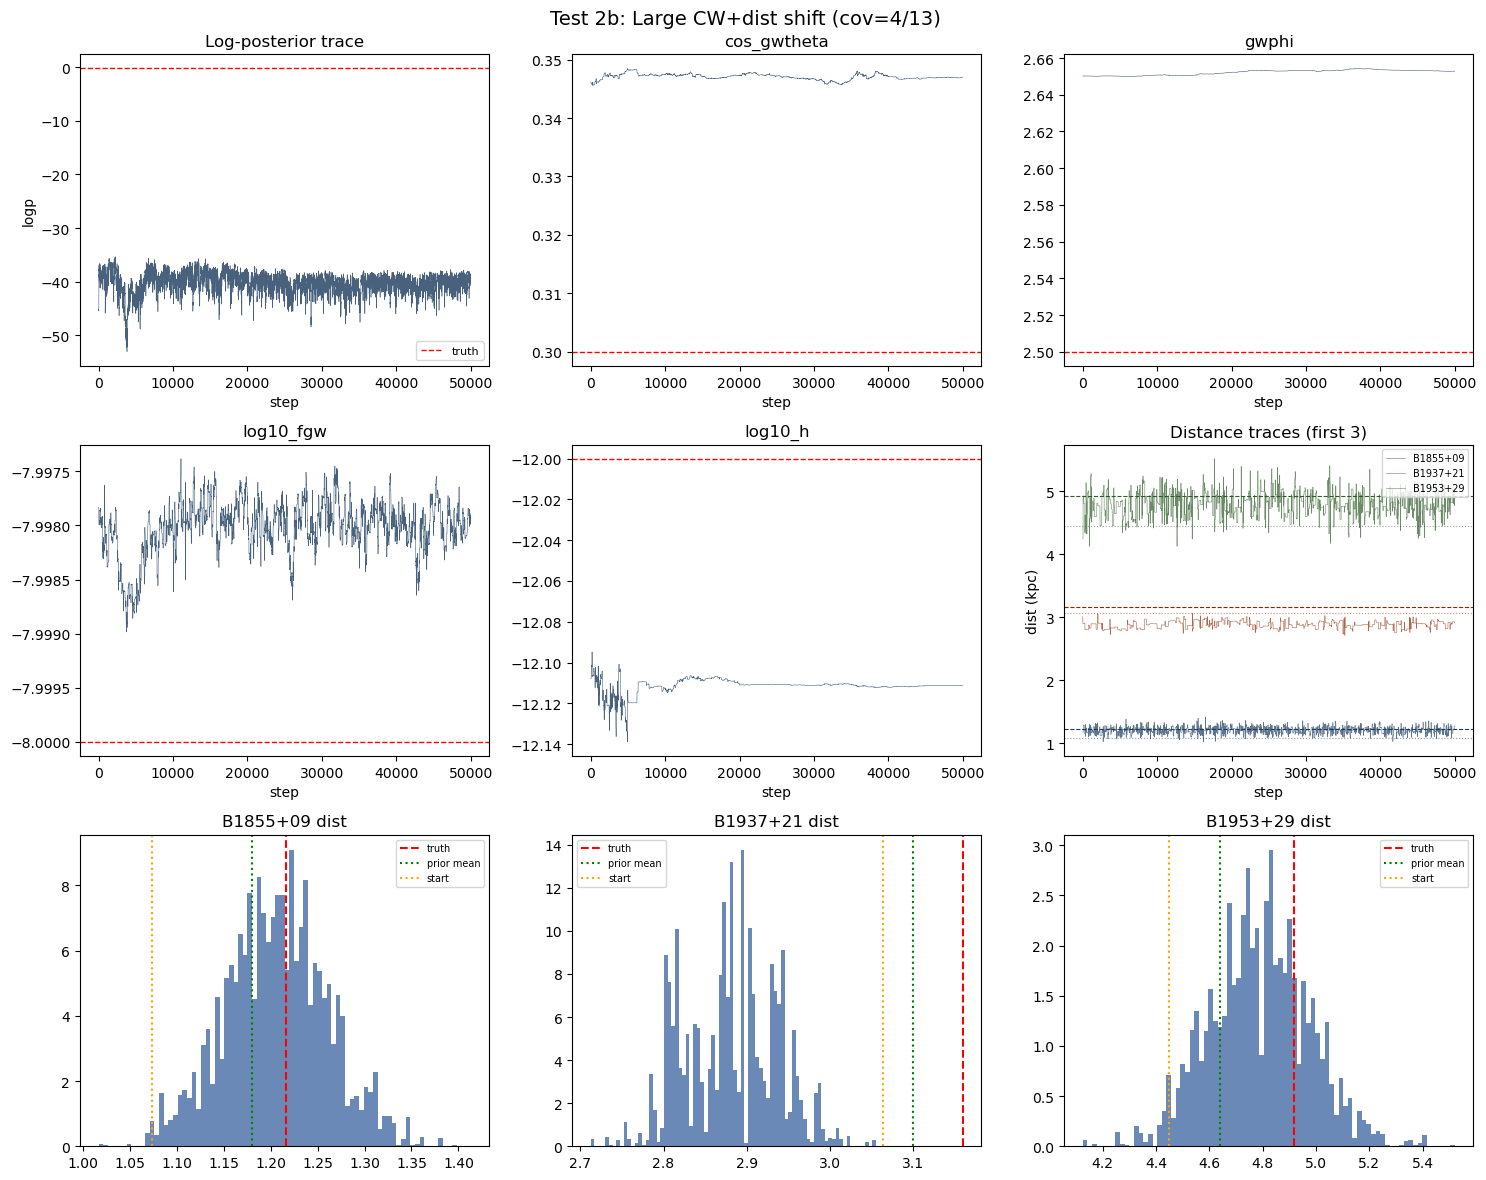

In [11]:
# ====== Test 2a: MODERATE offsets (CW within ~2-3 posterior std) ======
rng_shift = np.random.default_rng(789)

x_mod = p5_truth.copy()

# CW offsets ~2-3x posterior std (std from chain: cos_gwtheta~0.009, gwphi~0.001, etc.)
cw_offsets_mod = {
    'cos_gwtheta': 0.02,   # ~2x chain std
    'gwphi':       0.003,  # ~2x chain std
    'cos_inc':     0.08,   # ~2x chain std
    'log10_mc':    0.02,   # ~2x chain std
    'log10_fgw':   0.002,  # ~3x chain std
    'log10_h':     0.04,   # ~2.5x chain std
    'phase0':      0.15,   # ~2.5x chain std
    'psi':         0.04,   # ~2.5x chain std
}
print("Test 2a: MODERATE CW offsets (~2-3x posterior std):")
for i, (name, offset) in enumerate(cw_offsets_mod.items()):
    x_mod[i] = p5_truth[i] + offset
    print(f"  {name:15s}: {p5_truth[i]:.4f} -> {x_mod[i]:.4f} (delta={offset:+.4f})")

# Distance shifts within 2-sigma
print("\nShifting distances (within 2-sigma)...")
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]
    max_modes_up = int((mu_j + 2*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 2*sig_j, dL_j)) / dL_j)
    n_shift = rng_shift.integers(min(-max_modes_dn, -3), max(max_modes_up, 3)+1)
    if abs(n_shift) < 3:
        n_shift = rng_shift.choice([-5, 5])
    x_mod[8+j] += n_shift * dL_j
    x_mod[8+j] = np.clip(x_mod[8+j], dL_j, mu_j + 2*sig_j)

dL_mod = np.array(compute_delta_L(x_mod[0], x_mod[1], x_mod[4]))
for j in range(Npulsars):
    x_mod[8+j] = snap_to_peak(x_mod, j, float(dL_mod[j]), n_pts=200)

lp_mod = float(logp(jnp.array(x_mod)))
print(f"\n  logp = {lp_mod:.2f}  (truth = {lp_truth:.2f})")
for j in range(Npulsars):
    err_dL = abs(x_mod[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: err = {err_dL:.0f} dL from truth")

fisher_mod = compute_fisher(x_mod, logp)

chain2a, lps2a, ar2a = run_sampler(
    logp, x_mod.copy(), np.random.default_rng(42),
    fisher_dict=fisher_mod, dL_arr=dL_mod, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)

cov2a, ess2a = run_diagnostics(chain2a, lps2a, ar2a, p5_truth, dL_truth,
                              title='Test 2a: Moderate CW+dist shift',
                              show_start=x_mod)

# ====== Test 2b: LARGE offsets (CW ~5x posterior std) ======
rng_shift2 = np.random.default_rng(456)

x_hard = p5_truth.copy()

cw_offsets_hard = {
    'cos_gwtheta': 0.05,   # ~5x chain std
    'gwphi':       0.15,   # ~100x chain std (way off)
    'cos_inc':     0.1,    # ~2.5x chain std
    'log10_mc':    0.05,   # ~5x chain std
    'log10_fgw':   0.01,   # ~14x chain std
    'log10_h':     0.3,    # ~18x chain std
    'phase0':      0.5,    # ~8x chain std
    'psi':         0.2,    # ~12x chain std
}
print("\n\nTest 2b: LARGE CW offsets (~5-100x posterior std):")
for i, (name, offset) in enumerate(cw_offsets_hard.items()):
    x_hard[i] = p5_truth[i] + offset
    print(f"  {name:15s}: {p5_truth[i]:.4f} -> {x_hard[i]:.4f} (delta={offset:+.4f})")

# Distance shifts within 3-sigma
print("\nShifting distances (within 3-sigma)...")
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]
    max_modes_up = int((mu_j + 3*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 3*sig_j, dL_j)) / dL_j)
    n_shift = rng_shift2.integers(min(-max_modes_dn, -5), max(max_modes_up, 5)+1)
    if abs(n_shift) < 3:
        n_shift = rng_shift2.choice([-5, 5]) * rng_shift2.integers(1, 4)
    x_hard[8+j] += n_shift * dL_j
    x_hard[8+j] = np.clip(x_hard[8+j], dL_j, mu_j + 3*sig_j)

dL_hard = np.array(compute_delta_L(x_hard[0], x_hard[1], x_hard[4]))
for j in range(Npulsars):
    x_hard[8+j] = snap_to_peak(x_hard, j, float(dL_hard[j]), n_pts=200)

lp_hard = float(logp(jnp.array(x_hard)))
print(f"\n  logp = {lp_hard:.2f}  (truth = {lp_truth:.2f})")
for j in range(Npulsars):
    err_dL = abs(x_hard[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: err = {err_dL:.0f} dL from truth")

fisher_hard = compute_fisher(x_hard, logp)

chain2b, lps2b, ar2b = run_sampler(
    logp, x_hard.copy(), np.random.default_rng(42),
    fisher_dict=fisher_hard, dL_arr=dL_hard, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)

cov2b, ess2b = run_diagnostics(chain2b, lps2b, ar2b, p5_truth, dL_truth,
                              title='Test 2b: Large CW+dist shift',
                              show_start=x_hard)

Test 2b MK10 v2: LARGE CW offsets with run_sampler_mt (Fisher ext + DE + eigen reopt)
  Starting logp = -8699.51  (truth = -0.23)



  [Switching to empirical CW covariance at burn-in step 4000]
  Empirical CW std vs Fisher eigenmode widths:
    cos_gwtheta    : emp_std=1.52e-04, eig_sig=2.99e-07
    gwphi          : emp_std=5.30e-05, eig_sig=5.78e-06
    cos_inc        : emp_std=5.11e-02, eig_sig=7.85e-06
    log10_mc       : emp_std=1.87e-04, eig_sig=2.42e-04
    log10_fgw      : emp_std=1.31e-05, eig_sig=4.37e-03
    log10_h        : emp_std=9.21e-02, eig_sig=1.02e-02
    phase0         : emp_std=2.36e-02, eig_sig=2.79e-02
    psi            : emp_std=2.94e-02, eig_sig=2.99e-01
  New eigenmode widths: [5.94795673e-06 3.50641340e-05 9.27968128e-05 2.98103902e-04
 1.44824159e-02 4.11762124e-02 6.01686389e-02 2.55708573e-01]
  Computing Hessian...
  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [7.51297577e+02 2.81712032e+03 2.91824329e+04 1.23619087e+05
 8.90647327e+08 1.63792165e+10 3.24759022e+10 1.43576800e+13]
  Eigenmode proposal widths: [6.28108652e-07 1.32067618e-05 1.85964649e-05 7.97487845

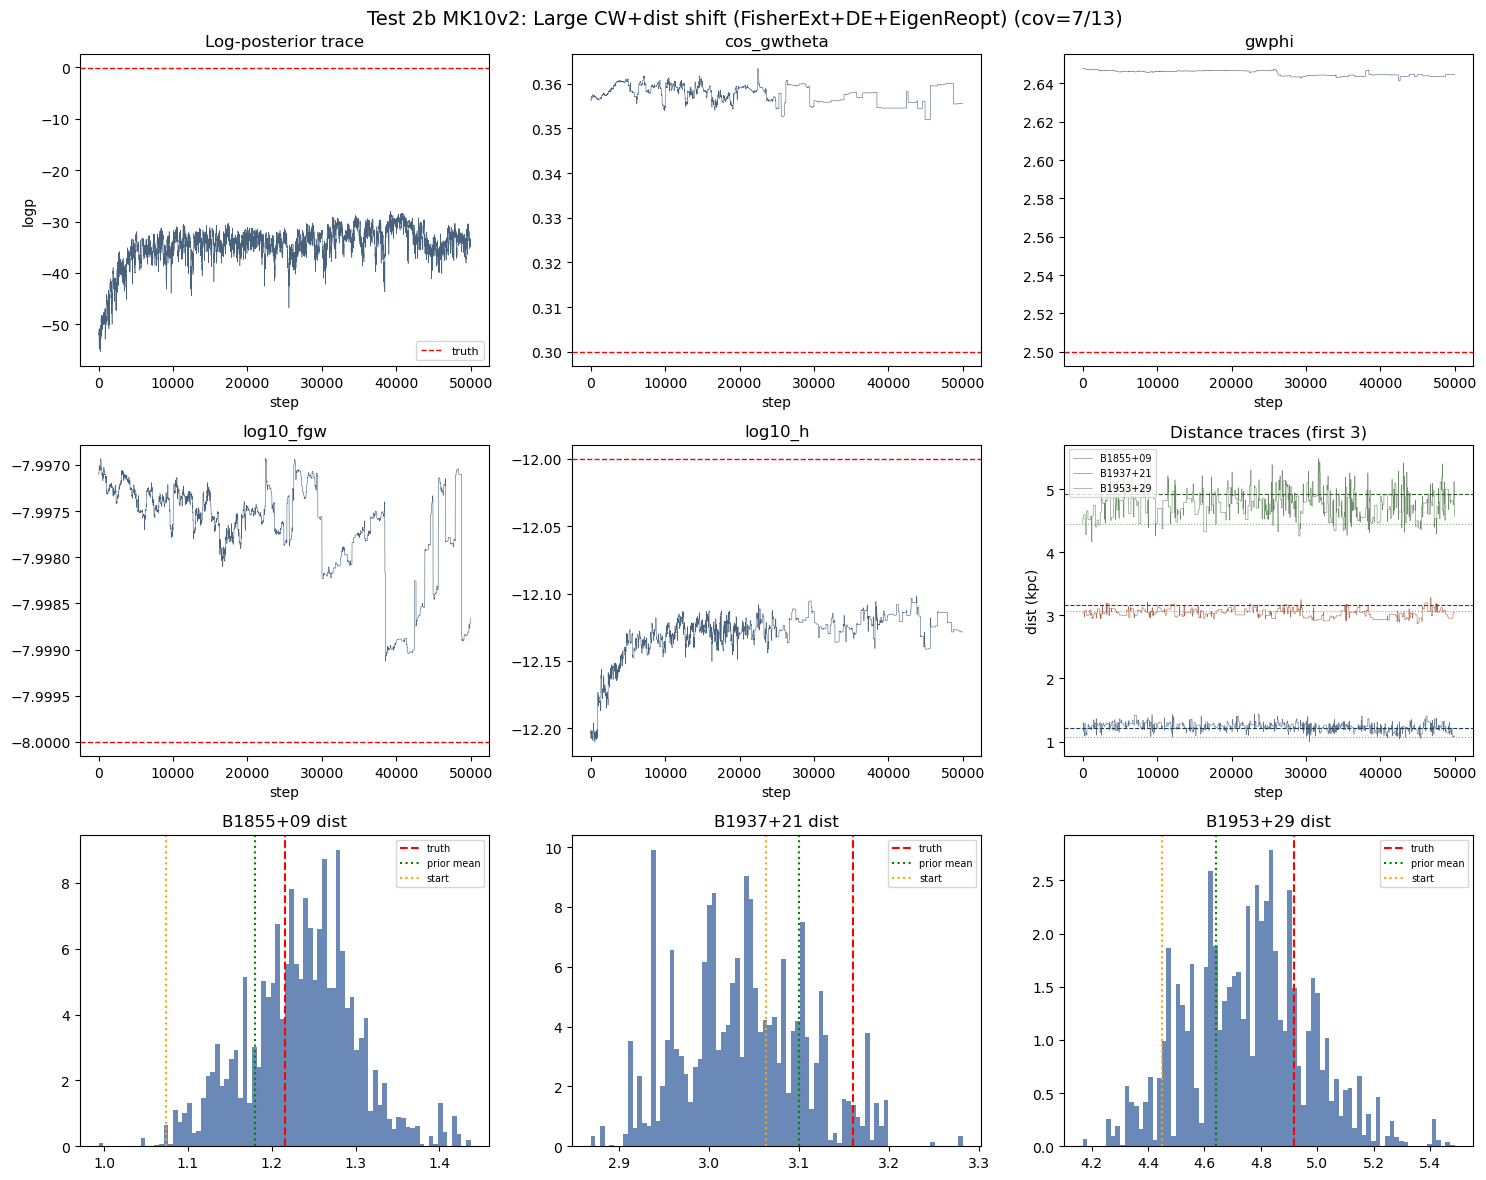

In [12]:
# ====== Test 2b MK10: Re-run with run_sampler_mt ======
# x_hard, fisher_hard, dL_hard already computed above

print("Test 2b MK10 v2: LARGE CW offsets with run_sampler_mt (Fisher ext + DE + eigen reopt)")
print(f"  Starting logp = {float(logp(jnp.array(x_hard))):.2f}  (truth = {lp_truth:.2f})\n")

chain2b_mt, lps2b_mt, ar2b_mt = run_sampler_mt(
    logp, x_hard.copy(), np.random.default_rng(42),
    fisher_dict=fisher_hard, dL_arr=dL_hard, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=5000,
    adapt_prod_steps=0)

cov2b_mt, ess2b_mt = run_diagnostics(chain2b_mt, lps2b_mt, ar2b_mt, p5_truth, dL_truth,
                                      title='Test 2b MK10v2: Large CW+dist shift (FisherExt+DE+EigenReopt)',
                                      show_start=x_hard)


## Test 3: Grid-search initialization + annealing — Large CW offsets

Same hard starting point as Test 2b, but using a proper two-step initialization:
1. **Step 1**: Coarse grid search — draw 8000 random CW param sets from the prior,
   batch-evaluate logp with `jax.vmap`, then run scipy L-BFGS-B (exact JAX gradients)
   from the top-30 candidates.  Zero speed overhead after the MCMC starts.
2. **Step 2**: Run `run_sampler_anneal` from the grid MAP, with T_start=30 cooling
   to T=1 during burn-in to correct any residual basin error.

No parallel chains — same single-chain speed (~400 it/s) as Test 1.


Test 3: Grid-search + annealing — Large CW offsets

Starting from Test 2b initial point  (logp=-8699.51)
Truth logp = -0.23

--- Step 1: Grid search + L-BFGS-B ---
  Stage 1: Earth-term-only grid eval (25x50x80x5 = 500000)


    first chunk compiled in 15.0s
    done in 15.5s, 495000/500000 valid, best grid logp = -2460.7

  Stage 2: sky-patch diversity: 5x10=50 patches + 25 global = 67 candidates
    cos_gwtheta [-1.0,-0.6): 10 cands
    cos_gwtheta [-0.6,-0.2): 11 cands
    cos_gwtheta [-0.2,+0.2): 10 cands
    cos_gwtheta [+0.2,+0.6): 10 cands
    cos_gwtheta [+0.6,+1.0): 26 cands

  Stage 3: distance coord-descent for 67 candidates
    pulsar 0: scan 1200 pts in [0.8200, 1.5400]
    pulsar 1: scan 2000 pts in [2.5000, 3.7000]
    pulsar 2: scan 9300 pts in [1.8500, 7.4300]
    pulsar 3: scan 1100 pts in [0.6900, 1.3500]
    pulsar 4: scan 100 pts in [0.3188, 0.3404]
    cand   0: logp=-884.28 sky=(0.833,5.404)
    cand   1: logp=-895.85 sky=(0.750,5.404)
    cand   2: logp=-832.08 sky=(0.667,5.278)
    cand  19: logp=-1158.28 sky=(0.917,3.644)
    cand  39: logp=-1527.61 sky=(0.917,0.503)
    cand  59: logp=-2012.21 sky=(0.917,2.513)
    cand  66: logp=-1565.22 sky=(0.167,1.257)
    done in 29.2s, best

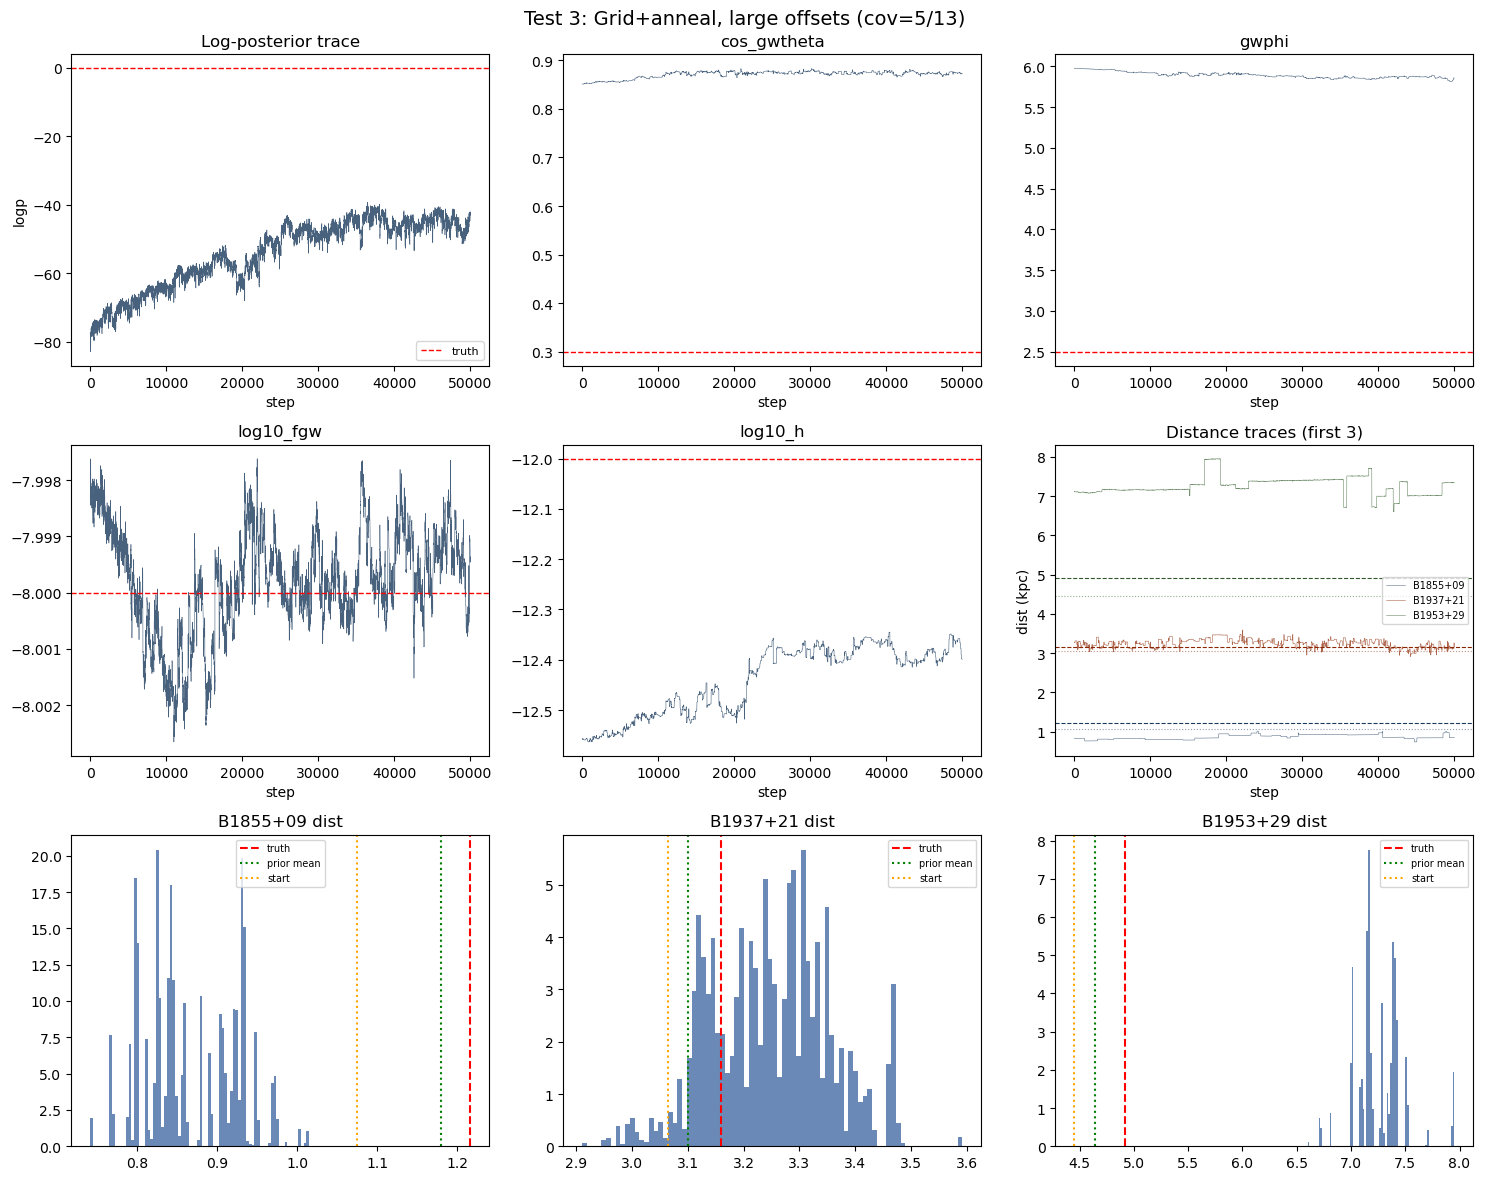

In [13]:

# Test 3: Grid-search initialization + annealing from large CW offsets
print("=" * 65)
print("Test 3: Grid-search + annealing — Large CW offsets")
print("=" * 65)
print(f"\nStarting from Test 2b initial point  (logp={lp_hard:.2f})")
print(f"Truth logp = {lp_truth:.2f}")

# --- Step 1: Coarse grid search + L-BFGS-B ---
print("\n--- Step 1: Grid search + L-BFGS-B ---")
t_grid_start = time.time()
x_grid, lp_grid = find_basin_grid(
    logp, grad_logp, mu_arr, sd_arr,
    logp_earth_fn=logp_earth, grad_logp_earth_fn=grad_logp_earth,
    n_top=50, max_opt_iter=300, seed=99)
t_grid = time.time() - t_grid_start
print(f"  Total time: {t_grid:.1f}s")

# Show MAP vs truth
print(f"\n  Grid MAP vs truth (logp={lp_grid:.3f}):")
cw_names_show = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                 'log10_fgw', 'log10_h', 'phase0', 'psi']
for i, name in enumerate(cw_names_show):
    delta = x_grid[i] - p5_truth[i]
    nsig  = delta / np.std(chain1[:, i]) if np.std(chain1[:, i]) > 0 else float('inf')
    print(f"    {name:15s}: found={x_grid[i]:.5f}, truth={p5_truth[i]:.5f}, "
          f"delta={delta:+.4f} ({nsig:+.1f} post.sigma)")
dL_grid = np.array(compute_delta_L(x_grid[0], x_grid[1], x_grid[4]))
for j in range(Npulsars):
    err_dL = abs(x_grid[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"    {disco_psrs[j].name:15s}: found={x_grid[8+j]:.5f}, "
          f"truth={p5_truth[8+j]:.5f},  err={err_dL:.1f} dL")

# Compute Fisher at grid MAP point
print(f"\n  Computing Fisher at grid MAP point:")
fisher_grid = compute_fisher(x_grid, logp)

# --- Step 2: Annealing sampler from grid MAP ---
print(f"\n--- Step 2: Annealing sampler (T_start=30, cool over 60% of burn-in) ---")
chain3, lps3, ar3 = run_sampler_anneal(
    logp, x_grid.copy(), np.random.default_rng(42),
    fisher_dict=fisher_grid, dL_arr=dL_grid, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    T_start=30.0, T_anneal_frac=0.6,
    adapt_prod_steps=0)

cov3, ess3 = run_diagnostics(chain3, lps3, ar3, p5_truth, dL_truth,
                              title='Test 3: Grid+anneal, large offsets',
                              show_start=x_hard)


In [14]:
# Side-by-side comparison: truth vs moderate vs large offsets vs MAP+anneal
print(f"{'='*95}")
print(f"{'':20s} {'Test 1':>15s} {'Test 2a':>15s} {'Test 2b':>15s} {'Test 3':>15s}")
print(f"{'':20s} {'(truth)':>15s} {'(moderate)':>15s} {'(large)':>15s} {'(MAP+anneal)':>15s}")
print(f"{'='*95}")
print(f"{'Coverage':20s} {cov1:>10d}/13   {cov2a:>10d}/13   {cov2b:>10d}/13   {cov3:>10d}/13")
print(f"{'ESS min':20s} {min(ess1.values()):>13.0f}   {min(ess2a.values()):>13.0f}   {min(ess2b.values()):>13.0f}   {min(ess3.values()):>13.0f}")
print(f"{'CW Eigen AR':20s} {ar1['cw_eigen']:>13.4f}   {ar2a['cw_eigen']:>13.4f}   {ar2b['cw_eigen']:>13.4f}   {ar3['cw_eigen']:>13.4f}")
print(f"{'Big jump AR':20s} {ar1['big_jump']:>13.4f}   {ar2a['big_jump']:>13.4f}   {ar2b['big_jump']:>13.4f}   {ar3['big_jump']:>13.4f}")
print(f"{'='*95}")

cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
           'log10_h', 'phase0', 'psi']
print(f"\nCW parameter ESS:")
print(f"  {'Param':20s} {'Test 1':>10s} {'Test 2a':>10s} {'Test 2b':>10s} {'Test 3':>10s}")
for k in cw_keys:
    print(f"  {k:20s} {ess1[k]:>10.0f} {ess2a[k]:>10.0f} {ess2b[k]:>10.0f} {ess3[k]:>10.0f}")

print(f"\nPer-pulsar distance errors (dL from truth):")
print(f"  {'Pulsar':13s} {'Test 1':>10s} {'Test 2a':>10s} {'Test 2b':>10s} {'Test 3':>10s}")
for j in range(Npulsars):
    med1 = np.median(chain1[:, 8+j])
    med2a = np.median(chain2a[:, 8+j])
    med2b = np.median(chain2b[:, 8+j])
    med3 = np.median(chain3[:, 8+j])
    err1 = abs(med1 - p5_truth[8+j]) / dL_truth[j]
    err2a = abs(med2a - p5_truth[8+j]) / dL_truth[j]
    err2b = abs(med2b - p5_truth[8+j]) / dL_truth[j]
    err3 = abs(med3 - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name:13s} {err1:>10.1f} {err2a:>10.1f} {err2b:>10.1f} {err3:>10.1f}")

                              Test 1         Test 2a         Test 2b          Test 3
                             (truth)      (moderate)         (large)    (MAP+anneal)
Coverage                     13/13           13/13            4/13            5/13
ESS min                         62              58              50              51
CW Eigen AR                 0.2039          0.2135          0.2306          0.2078
Big jump AR                 0.3815          0.3776          0.4073          0.2617

CW parameter ESS:
  Param                    Test 1    Test 2a    Test 2b     Test 3
  cos_gwtheta                  73         62         55         55
  gwphi                        69         63         50         53
  cos_inc                      75         74         54         54
  log10_mc                     62         62         53         59
  log10_fgw                    81         63         78         63
  log10_h                      67         68         72         51
  phase0  